In [27]:
import matplotlib.pyplot as plt
from msca import *
import os
import importlib
import msca
import msca.models
import msca.architectures
import msca.utils
import msca.simulations
import msca.evaluations
from msca.evaluations import evaluate_trial_average
# Suppress MallocStackLogging warnings on macOS
os.environ["MallocStackLogging"] = "0"

# Reload msca and key submodules after code changes
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca)
importlib.reload(msca.simulations)
importlib.reload(msca.evaluations)

# Re-import updated symbols
from msca import *




In [28]:
import scipy.io as sio
mat = sio.loadmat("./data/Cousteau_interp_cycling_m1_rawRates.mat")
mask = mat["mask"]


In [29]:
import importlib
import os
import numpy as np
from scipy import io


def load_data(dir_path, f):
    # Load in matlab file
    mat_file = io.loadmat(dir_path + f)

    # Grab data and mask
    data_array = mat_file["data"]
    mask = mat_file["mask"]

    # Grab the start and end indices for each trial
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()

    return data_array, mask, start_idxs, end_idxs


# Preprocess the loaded data and split into trials
def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    """
    Pre-processing done by Andrew Zimnik
    """
    # Downsample the data
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]

        # Adjust the start and end indices to account for the downsampling
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    # Transpose the data to N x TC
    data_concat = data_downsamp.T

    # fr range (for normalizing later)
    fr_range = np.ptp(data_concat, axis=1)[:, None]

    # Soft normalize (divide each neuron by its range + 5)
    data_norm = data_concat / (fr_range + 5)

    # mean-center each neuron
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]

    # rename the data for convenience
    # Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
    fit_data = np.copy(data_snm_norm.T)

    # Split the data into trials
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

    return split_data



fp = "./data/"
m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_m1_rawRates.mat"
)
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_sma_rawRates.mat"
)

# Preprocess the data
m1_preprocessed = preprocess(
    m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5
)
sma_preprocessed = preprocess(
    sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5
)

# Put data into dictionary format
X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


## Load Saved Neuron Split Indices




In [30]:
# nonlinear nonlinear : all split are identical 
experiment_path = "./results/bi-cross-validation-Cousteau-model-2/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-orthog-0.1/"

train_split_path = os.path.join(experiment_path, "n_train_splits.pt")
test_split_path  = os.path.join(experiment_path, "n_test_splits.pt")

train_idxs = torch.load(train_split_path, weights_only=False)
test_idxs  = torch.load(test_split_path, weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}:  train neurons per fold = {[len(t) for t in train_idxs[k]]}, "
          f"test neurons per fold = {[len(t) for t in test_idxs[k]]}")


Number of folds: 5
  M1:  train neurons per fold = [92, 93, 93, 93, 93], test neurons per fold = [24, 23, 23, 23, 23]
  SMA:  train neurons per fold = [61, 61, 62, 62, 62], test neurons per fold = [16, 16, 15, 15, 15]


# New model check

In [ ]:
from pathlib import Path
import numpy as np
import torch
from sklearn.metrics import r2_score

from msca import mSCA
from msca.evaluations import evaluate_trial_average


def _align_trial(pred_trial, actual_trial, trunc):
    pred = np.asarray(pred_trial)
    true = np.asarray(actual_trial)[trunc]
    t = min(pred.shape[0], true.shape[0])
    n = min(pred.shape[1], true.shape[1])
    return pred[:t, :n], true[:t, :n]


def compute_region_r2_from_predictions(predictions, X_val, trunc):
    r2_region = {}
    for region in X_val.keys():
        y_true_trials, y_pred_trials = [], []
        for pred_trial, actual_trial in zip(predictions[region], X_val[region]):
            pred_t, true_t = _align_trial(pred_trial, actual_trial, trunc)
            y_pred_trials.append(pred_t)
            y_true_trials.append(true_t)

        y_true = np.concatenate(y_true_trials, axis=0)
        y_pred = np.concatenate(y_pred_trials, axis=0)
        r2_region[region] = float(r2_score(y_true, y_pred, multioutput="uniform_average"))
    return r2_region


# ---------- Evaluate nonlinear encoder + triple-layer decoder ----------
n_components = 30
regions = ["M1", "SMA"]
readout_modes = ["linear", "mlp"]

# Cache fold-wise triple-layer n=10 checkpoints for reuse
triple_ckpt_root = Path("./results/evaluation/triple_layer_n10")
triple_ckpt_root.mkdir(parents=True, exist_ok=True)

# Collect per-fold R²
results_triple = {
    mode: {region: [] for region in regions}
    for mode in readout_modes
}

for fold in range(n_folds):
    X_train = {k: [trial[:, train_idxs[k][fold]] for trial in v] for k, v in X.items()}
    X_val = {k: [trial[:, test_idxs[k][fold]] for trial in v] for k, v in X.items()}

    ckpt_path = triple_ckpt_root / f"msca_triple_layer_n10_split_{fold}.pt"

    msca = mSCA(
        n_components=n_components,
        n_epochs=1200,
        loss_func="Gaussian",
        lr=1e-3,
        filter_len=41,
        linear=False,
        region_weights=None,
        lam_sparse=2.5,
        lam_orthog=0.1,
        lam_region=None,
        batch_size=64,
        cd_rate=0.5,
        decoder_type="triple_layer",
        decoder_hidden_size=n_components,
        decoder_activation="GeLU",
        device="cpu",
        cd_mode="both",
        post_hoc_epoch=-1,
    )

    if ckpt_path.exists():
        msca.load(str(ckpt_path), X_train)
        source = "loaded"
    else:
        msca, _ = msca.fit(X_train)
        msca.save(str(ckpt_path))
        source = "trained"

    fold_msg = [f"Fold {fold} | {source}: {ckpt_path.name}"]

    for mode in readout_modes:
        # evaluate_trial_average returns the held-out predictions across folds
        predictions = evaluate_trial_average(msca, X_train, X_val, mode, n_splits=5)
        r2s = compute_region_r2_from_predictions(predictions, X_val, trunc=msca.trunc)
        for region in regions:
            results_triple[mode][region].append(r2s[region])
        fold_msg.append(f"{mode.upper()} -> M1: {r2s['M1']:.4f}, SMA: {r2s['SMA']:.4f}")

    print(" | ".join(fold_msg))


print("\n=== Summary: Nonlinear Encoder + Triple-Layer Decoder (n_components=10) ===")
for region in regions:
    lr_vals = np.array(results_triple["linear"][region], dtype=float)
    mlp_vals = np.array(results_triple["mlp"][region], dtype=float)

    print(
        f"{region}: "
        f"LR R² = {np.nanmean(lr_vals):.4f} ± {np.nanstd(lr_vals):.4f} | "
        f"MLP R² = {np.nanmean(mlp_vals):.4f} ± {np.nanstd(mlp_vals):.4f}"
    )

r2_compare_table = {
    region: {
        "linear_mean": float(np.nanmean(results_triple["linear"][region])),
        "linear_std": float(np.nanstd(results_triple["linear"][region])),
        "mlp_mean": float(np.nanmean(results_triple["mlp"][region])),
        "mlp_std": float(np.nanstd(results_triple["mlp"][region])),
    }
    for region in regions
}

print("\nr2_compare_table:")
print(r2_compare_table)

predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
Fold 0 | loaded: msca_triple_layer_n10_split_0.pt | LINEAR -> M1: 0.4172, SMA: 0.3491 | MLP -> M1: 0.5752, SMA: 0.3963
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
Fold 1 | loaded: msca_triple_layer_n10_split_1.pt | LINEAR -> M1: 0.4565, SMA: 0.3456 | MLP -> M1: 0.5809, SMA: 0.4127
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
Fold 2 | loaded: msca_triple_layer_n10_split_2.pt | LINEAR -> M1: 0.4524, SMA: 0.4427 | MLP -> M1: 0.5294, SMA: 0.4943
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
Fold 3 | loaded: msca_triple_layer_n10_split_3.pt | LINEAR -> M1: 0.4943, SMA: 0.3232 | MLP -> M1: 0.5736, SMA: 0.3718
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
Fold 4 | loade

# Sanity_check 
- MLP readout will make the R2 value greatly larger than using LR readout for all three types of models.



Using n_components: [10, 16, 26, 36, 46, 50]

Model: linear-linear | folds=5


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}


...

predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}

Model: nonlinear-nonlinear | folds=5
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA': 20}
predictions container shape: {'M1': 20, 'SMA

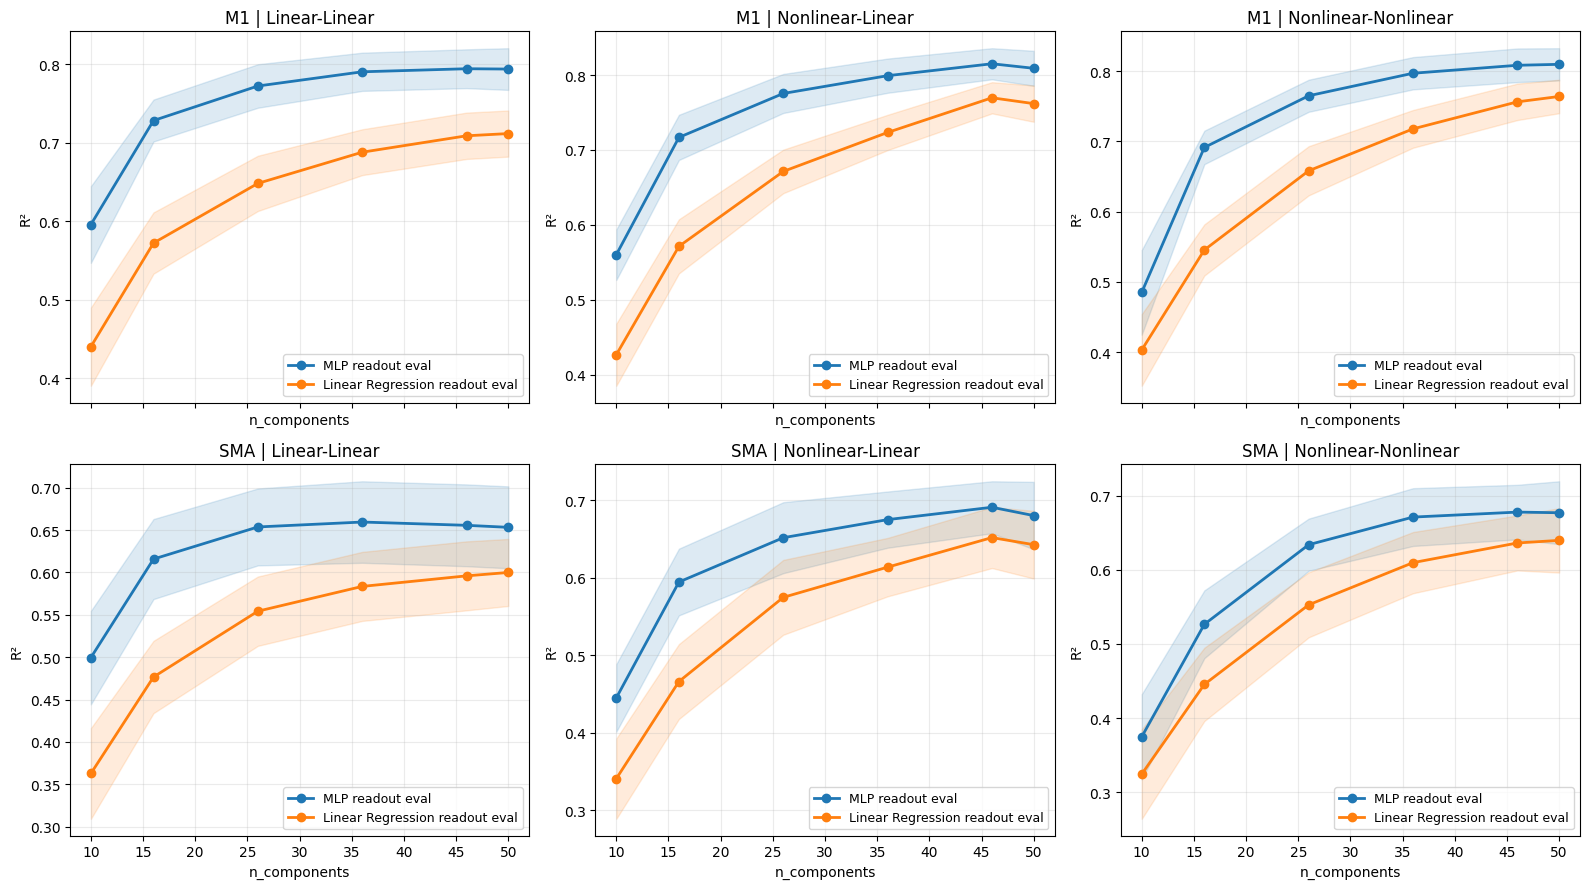

In [32]:
import os
import re
from pathlib import Path

import numpy as np
import torch
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy import io
from sklearn.metrics import r2_score

from msca import mSCA
from msca.evaluations import evaluate_trial_average

# ---------- Ensure data dictionary X exists ----------
if "X" not in globals():
    def load_data(dir_path, f):
        mat_file = io.loadmat(dir_path + f)
        data_array = mat_file["data"]
        mask = mat_file["mask"]
        start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
        end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()
        return data_array, mask, start_idxs, end_idxs

    def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
        if downsample_factor is not None:
            data_downsamp = data_array[::downsample_factor]
            start_idxs = start_idxs // downsample_factor
            end_idxs = end_idxs // downsample_factor
        else:
            data_downsamp = data_array

        data_concat = data_downsamp.T
        fr_range = np.ptp(data_concat, axis=1)[:, None]
        data_norm = data_concat / (fr_range + 5)
        data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]
        fit_data = np.copy(data_snm_norm.T)
        split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]
        return split_data

    fp = "./data/"
    m1_data, _, m1_start_idxs, m1_end_idxs = load_data(fp, "Cousteau_interp_cycling_m1_rawRates.mat")
    sma_data, _, sma_start_idxs, sma_end_idxs = load_data(fp, "Cousteau_interp_cycling_sma_rawRates.mat")

    m1_preprocessed = preprocess(m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5)
    sma_preprocessed = preprocess(sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5)
    X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


def _align_trial(pred_trial, actual_trial, trunc):
    pred = np.asarray(pred_trial)
    true = np.asarray(actual_trial)[trunc]
    t = min(pred.shape[0], true.shape[0])
    n = min(pred.shape[1], true.shape[1])
    return pred[:t, :n], true[:t, :n]


def compute_region_r2(predictions, X_val, trunc):
    r2_region = {}
    for region in X_val.keys():
        y_true_trials, y_pred_trials = [], []
        for pred_trial, actual_trial in zip(predictions[region], X_val[region]):
            pred_t, true_t = _align_trial(pred_trial, actual_trial, trunc)
            y_pred_trials.append(pred_t)
            y_true_trials.append(true_t)

        y_true = np.concatenate(y_true_trials, axis=0)
        y_pred = np.concatenate(y_pred_trials, axis=0)
        r2_region[region] = float(r2_score(y_true, y_pred, multioutput="uniform_average"))
    return r2_region


# ---------- Experiment setup ----------
base = Path("./results/bi-cross-validation-Cousteau-model-2")
experiment_configs = {
    "linear-linear": {
        "root": base / "bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5-orthog-0.1",
        "linear": True,
        "decoder_type": "linear",
    },
    "nonlinear-linear": {
        "root": base / "bi-cross-validation-Cousteau-nonlinear-linear-lamsparse-2.5-orthog-0.1",
        "linear": False,
        "decoder_type": "linear",
    },
    "nonlinear-nonlinear": {
        "root": base / "bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-orthog-0.1",
        "linear": False,
        "decoder_type": "triple_layer",
    },
}

readout_modes = ["mlp", "linear"]  # MLP readout and linear-regression readout
regions = ["M1", "SMA"]

# find common n_components present in all three model folders
common_components = None
for cfg in experiment_configs.values():
    comps = {
        int(m.group(1))
        for p in cfg["root"].glob("n_components_*")
        if (m := re.match(r"n_components_(\d+)$", p.name))
    }
    common_components = comps if common_components is None else (common_components & comps)

n_components_list = sorted(common_components)
n_components_list =[10, 16,26,36,46,50]
print("Using n_components:", n_components_list)

# results[model][readout][region][n_components] -> list over folds
results = {
    model: {
        mode: {region: {nc: [] for nc in n_components_list} for region in regions}
        for mode in readout_modes
    }
    for model in experiment_configs
}

for model_name, cfg in experiment_configs.items():
    root = cfg["root"]
    train_idxs = torch.load(root / "n_train_splits.pt", weights_only=False)
    test_idxs = torch.load(root / "n_test_splits.pt", weights_only=False)
    n_folds = len(train_idxs[regions[0]])

    print(f"\nModel: {model_name} | folds={n_folds}")

    for nc in n_components_list:
        model_dir = root / f"n_components_{nc}"

        for fold in range(n_folds):
            model_fp = model_dir / f"msca_split_{fold}.pt"
            if not model_fp.exists():
                continue

            X_train = {k: [trial[:, train_idxs[k][fold]] for trial in v] for k, v in X.items()}
            X_val = {k: [trial[:, test_idxs[k][fold]] for trial in v] for k, v in X.items()}

            msca = mSCA(
                n_components=nc,
                n_epochs=5000,
                loss_func="Gaussian",
                lr=1e-3,
                filter_len=41,
                linear=cfg["linear"],
                region_weights=None,
                lam_sparse=2.5,
                lam_orthog=0.1,
                lam_region=None,
                batch_size=64,
                cd_rate=0.5,
                decoder_type=cfg["decoder_type"],
                device="cpu",
                cd_mode="both",
                post_hoc_epoch=-1,
            )

            msca.load(str(model_fp), X_train)

            for mode in readout_modes:
                preds = evaluate_trial_average(msca, X_train, X_val, mode, n_splits=5)
                r2s = compute_region_r2(preds, X_val, trunc=msca.trunc)
                for region in regions:
                    results[model_name][mode][region][nc].append(r2s[region])


# ---------- Aggregate and plot: 2 rows x 3 cols ----------
model_order = ["linear-linear", "nonlinear-linear", "nonlinear-nonlinear"]
model_titles = {
    "linear-linear": "Linear-Linear",
    "nonlinear-linear": "Nonlinear-Linear",
    "nonlinear-nonlinear": "Nonlinear-Nonlinear",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)


# model_order = ["linear-linear","nonlinear-nonlinear"]
# model_titles = {
#     "linear-linear": "Linear-Linear",
#     "nonlinear-nonlinear": "Nonlinear-Nonlinear",
# }

# fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)

for r, region in enumerate(regions):
    for c, model_name in enumerate(model_order):
        ax = axes[r, c]

        for mode, color, label in [
            ("mlp", "tab:blue", "MLP readout eval"),
            ("linear", "tab:orange", "Linear Regression readout eval"),
        ]:
            xs, ys, yerr = [], [], []
            for nc in n_components_list:
                vals = np.array(results[model_name][mode][region][nc], dtype=float)
                if vals.size == 0:
                    continue
                xs.append(nc)
                ys.append(np.nanmean(vals))
                yerr.append(np.nanstd(vals))

            if len(xs) > 0:
                ax.plot(xs, ys, marker="o", linewidth=2, color=color, label=label)
                ax.fill_between(
                    xs,
                    np.array(ys) - np.array(yerr),
                    np.array(ys) + np.array(yerr),
                    color=color,
                    alpha=0.15,
                )

        ax.set_title(f"{region} | {model_titles[model_name]}")
        ax.set_xlabel("n_components")
        ax.set_ylabel("R²")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
from pathlib import Path
import csv
import pickle

# Save R² values for reuse
cache_dir = Path("./results/evaluation/2")
cache_dir.mkdir(parents=True, exist_ok=True)

pkl_path = cache_dir / "r2_dim_curves_cache.pkl"
csv_path = cache_dir / "r2_dim_curves_long.csv"

payload = {
    "results": results,
    "n_components_list": n_components_list,
    "regions": regions,
    "model_order": model_order,
    "readout_modes": readout_modes,
}
    
with open(pkl_path, "wb") as f:
    pickle.dump(payload, f)

# Also save a long-format CSV for easy plotting/analysis later
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model", "readout", "region", "n_components", "fold", "r2"])
    for model_name, by_readout in results.items():
        for mode, by_region in by_readout.items():
            for region, by_nc in by_region.items():
                for nc, vals in by_nc.items():
                    for fold_idx, val in enumerate(vals):
                        writer.writerow([model_name, mode, region, nc, fold_idx, float(val)])

print(f"Saved cache: {pkl_path}")
print(f"Saved table: {csv_path}")
print("Reuse example:")
print("  with open('./results/r2_dim_curves_cache.pkl', 'rb') as f:")
print("      cache = pickle.load(f)")
print("      results = cache['results']")

Saved cache: results/evaluation/2/r2_dim_curves_cache.pkl
Saved table: results/evaluation/2/r2_dim_curves_long.csv
Reuse example:
  with open('./results/r2_dim_curves_cache.pkl', 'rb') as f:
      cache = pickle.load(f)
      results = cache['results']


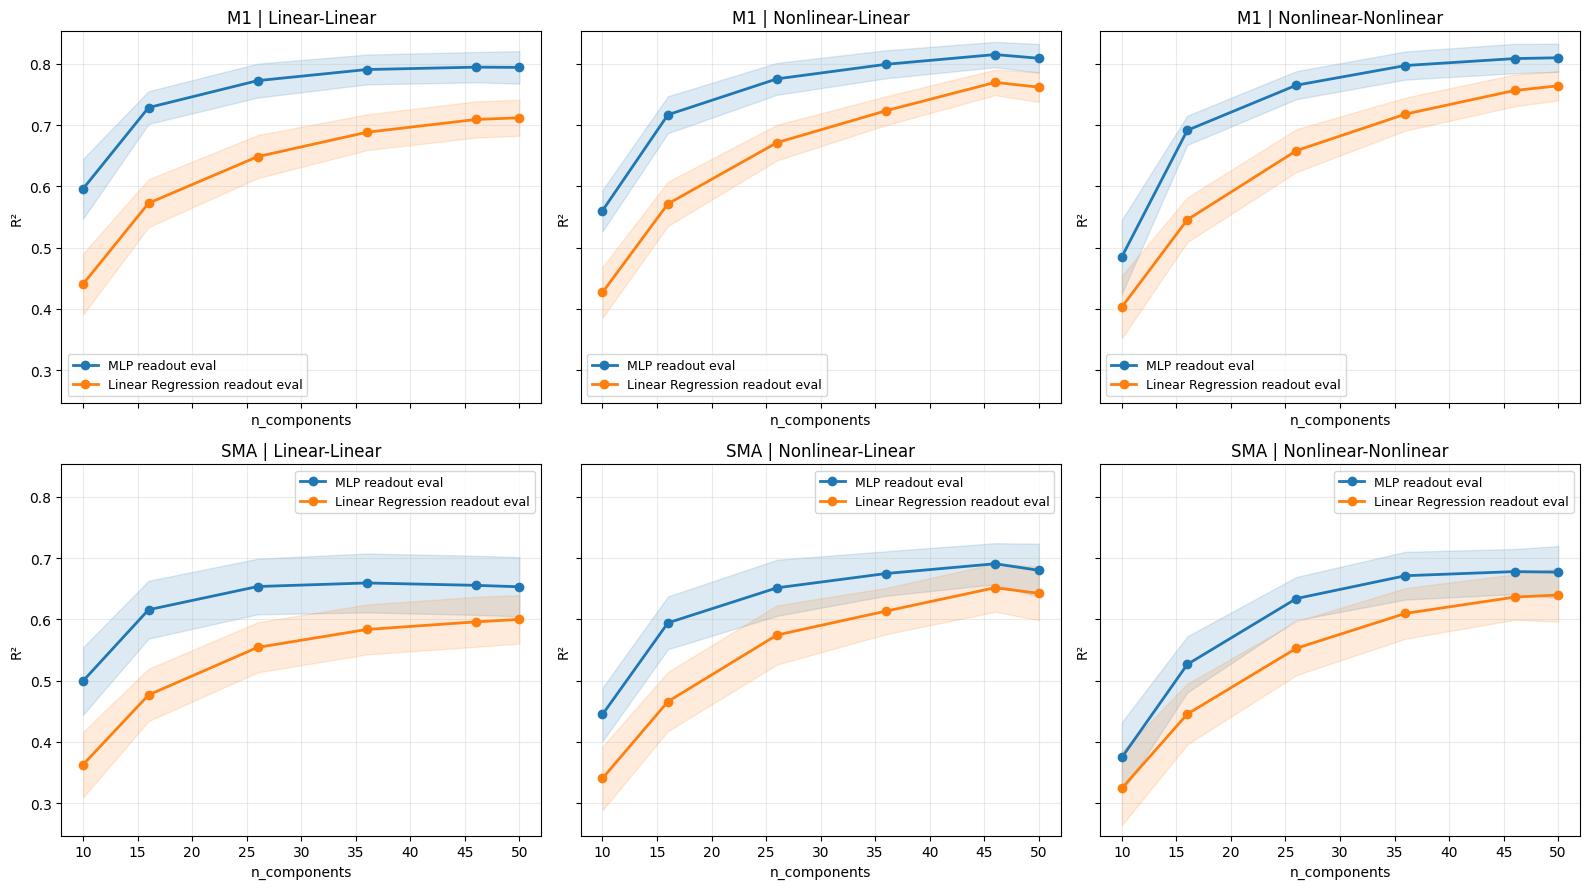

Applied shared y-axis limits to all subplots: [0.247, 0.853]


In [36]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Reuse in-memory results if available; otherwise load from saved cache
if "results" not in globals() or "n_components_list" not in globals():
    cache_candidates = [
        Path("./results/evaluation/2/r2_dim_curves_cache.pkl"),
        Path("./results/r2_dim_curves_cache.pkl"),
    ]
    cache_path = next((p for p in cache_candidates if p.exists()), None)
    if cache_path is None:
        raise FileNotFoundError(
            "No cache file found. Run the evaluation cell first (or the save cell)."
        )

    with open(cache_path, "rb") as f:
        cache = pickle.load(f)

    results = cache["results"]
    n_components_list = cache["n_components_list"]
    regions = cache["regions"]
    model_order = cache["model_order"]
    readout_modes = cache["readout_modes"]
else:
    model_order = ["linear-linear", "nonlinear-linear", "nonlinear-nonlinear"]
    regions = ["M1", "SMA"]

model_titles = {
    "linear-linear": "Linear-Linear",
    "nonlinear-linear": "Nonlinear-Linear",
    "nonlinear-nonlinear": "Nonlinear-Nonlinear",
}
# else:
#     model_order = ["linear-linear",  "nonlinear-nonlinear"]
#     regions = ["M1", "SMA"]

# model_titles = {
#     "linear-linear": "Linear-Linear",
#     "nonlinear-nonlinear": "Nonlinear-Nonlinear",
# }

# ---------- Compute one global y-range for all 6 subplots ----------
global_lows = []
global_highs = []

for region in regions:
    for model_name in model_order:
        for mode in readout_modes:
            vals_mean = []
            vals_std = []
            for nc in n_components_list:
                vals = np.array(results[model_name][mode][region][nc], dtype=float)
                if vals.size == 0:
                    continue
                vals_mean.append(np.nanmean(vals))
                vals_std.append(np.nanstd(vals))

            if len(vals_mean) > 0:
                vals_mean = np.array(vals_mean)
                vals_std = np.array(vals_std)
                global_lows.append(np.min(vals_mean - vals_std))
                global_highs.append(np.max(vals_mean + vals_std))

if len(global_lows) == 0 or len(global_highs) == 0:
    raise ValueError("No R² values found to plot.")

ymin = float(np.min(global_lows))
ymax = float(np.max(global_highs))
padding = 0.03 * (ymax - ymin if ymax > ymin else 1.0)
ymin -= padding
ymax += padding

# ---------- Plot with the same y-axis scale ----------
# fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
for r, region in enumerate(regions):
    for c, model_name in enumerate(model_order):
        ax = axes[r, c]

        for mode, color, label in [
            ("mlp", "tab:blue", "MLP readout eval"),
            ("linear", "tab:orange", "Linear Regression readout eval"),
        ]:
            xs, ys, yerr = [], [], []
            for nc in n_components_list:
                vals = np.array(results[model_name][mode][region][nc], dtype=float)
                if vals.size == 0:
                    continue
                xs.append(nc)
                ys.append(np.nanmean(vals))
                yerr.append(np.nanstd(vals))

            if len(xs) > 0:
                ax.plot(xs, ys, marker="o", linewidth=2, color=color, label=label)
                ax.fill_between(
                    xs,
                    np.array(ys) - np.array(yerr),
                    np.array(ys) + np.array(yerr),
                    color=color,
                    alpha=0.15,
                )

        ax.set_title(f"{region} | {model_titles[model_name]}")
        ax.set_xlabel("n_components")
        ax.set_ylabel("R²")
        ax.grid(alpha=0.25)
        ax.set_ylim(ymin, ymax)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Applied shared y-axis limits to all subplots: [{ymin:.3f}, {ymax:.3f}]")

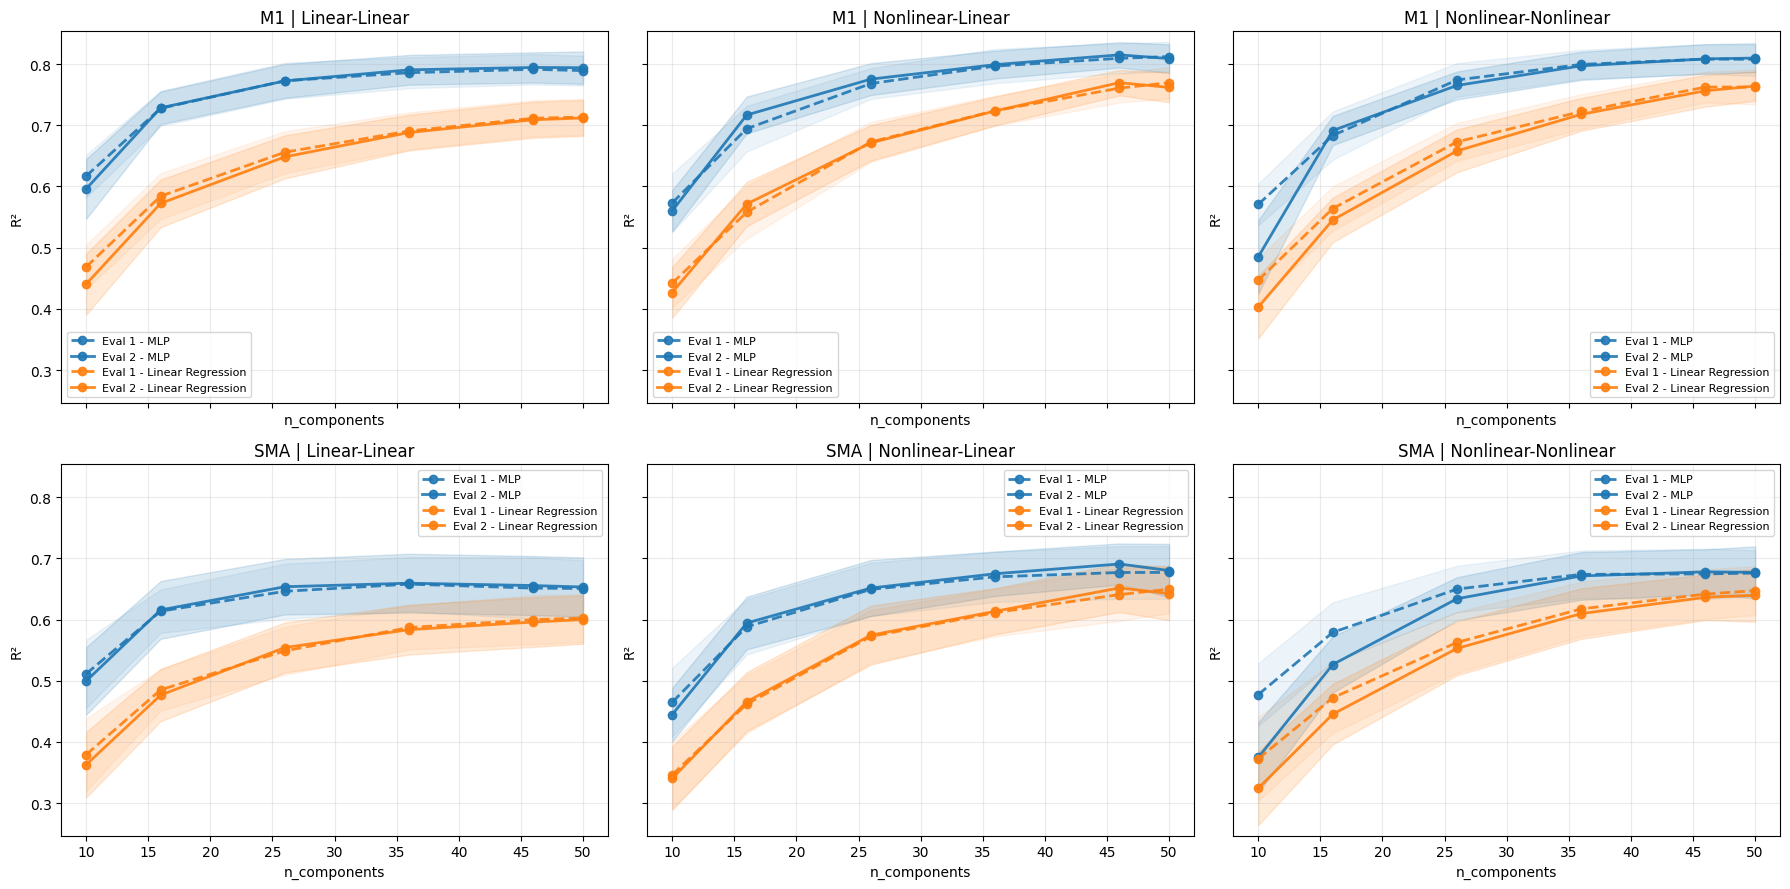

Applied shared y-axis limits to all 6 subplots: [0.247, 0.853]
Line style: dashed = Evaluation 1, solid = Evaluation 2


In [37]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load both cached evaluations ----------
cache_eval1 = Path("./results/evaluation/1/r2_dim_curves_cache.pkl")
cache_eval2 = Path("./results/evaluation/2/r2_dim_curves_cache.pkl")

if not cache_eval1.exists() or not cache_eval2.exists():
    raise FileNotFoundError(
        "Missing cache file(s). Expected:\n"
        "- ./results/evaluation/1/r2_dim_curves_cache.pkl\n"
        "- ./results/evaluation/2/r2_dim_curves_cache.pkl"
    )

with open(cache_eval1, "rb") as f:
    eval1 = pickle.load(f)

with open(cache_eval2, "rb") as f:
    eval2 = pickle.load(f)

results1 = eval1["results"]
results2 = eval2["results"]

# enforce common plotting schema (6 subplots)
model_order = ["linear-linear", "nonlinear-linear", "nonlinear-nonlinear"]
model_titles = {
    "linear-linear": "Linear-Linear",
    "nonlinear-linear": "Nonlinear-Linear",
    "nonlinear-nonlinear": "Nonlinear-Nonlinear",
}
regions = ["M1", "SMA"]
readout_modes = ["mlp", "linear"]

# common n_components per model across both evaluations
n_components_by_model = {}
for model_name in model_order:
    ncs1 = set()
    ncs2 = set()

    if model_name in results1:
        for mode in readout_modes:
            for region in regions:
                ncs1 |= set(results1[model_name][mode][region].keys())

    if model_name in results2:
        for mode in readout_modes:
            for region in regions:
                ncs2 |= set(results2[model_name][mode][region].keys())

    n_components_by_model[model_name] = sorted(ncs1 & ncs2)


# ---------- Compute one global y-range for all 6 subplots ----------
global_lows, global_highs = [], []

def collect_range(results_dict):
    for region in regions:
        for model_name in model_order:
            if model_name not in results_dict:
                continue
            for mode in readout_modes:
                vals_mean, vals_std = [], []
                for nc in n_components_by_model[model_name]:
                    vals = np.array(results_dict[model_name][mode][region].get(nc, []), dtype=float)
                    if vals.size == 0:
                        continue
                    vals_mean.append(np.nanmean(vals))
                    vals_std.append(np.nanstd(vals))
                if len(vals_mean) > 0:
                    vals_mean = np.array(vals_mean)
                    vals_std = np.array(vals_std)
                    global_lows.append(np.min(vals_mean - vals_std))
                    global_highs.append(np.max(vals_mean + vals_std))

collect_range(results1)
collect_range(results2)

if len(global_lows) == 0 or len(global_highs) == 0:
    raise ValueError("No R² values found in evaluation caches.")

ymin = float(np.min(global_lows))
ymax = float(np.max(global_highs))
padding = 0.03 * (ymax - ymin if ymax > ymin else 1.0)
ymin -= padding
ymax += padding


# ---------- Plot: 2 rows x 3 cols ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)

for r, region in enumerate(regions):
    for c, model_name in enumerate(model_order):
        ax = axes[r, c]

        for mode, color, label_base in [
            ("mlp", "tab:blue", "MLP"),
            ("linear", "tab:orange", "Linear Regression"),
        ]:
            # Evaluation 1 (dashed)
            if model_name in results1:
                xs1, ys1, yerr1 = [], [], []
                for nc in n_components_by_model[model_name]:
                    vals = np.array(results1[model_name][mode][region].get(nc, []), dtype=float)
                    if vals.size == 0:
                        continue
                    xs1.append(nc)
                    ys1.append(np.nanmean(vals))
                    yerr1.append(np.nanstd(vals))
                if len(xs1) > 0:
                    ax.plot(
                        xs1,
                        ys1,
                        marker="o",
                        linewidth=2,
                        linestyle="--",
                        color=color,
                        alpha=0.9,
                        label=f"Eval 1 - {label_base}",
                    )
                    ax.fill_between(
                        xs1,
                        np.array(ys1) - np.array(yerr1),
                        np.array(ys1) + np.array(yerr1),
                        color=color,
                        alpha=0.08,
                    )

            # Evaluation 2 (solid)
            if model_name in results2:
                xs2, ys2, yerr2 = [], [], []
                for nc in n_components_by_model[model_name]:
                    vals = np.array(results2[model_name][mode][region].get(nc, []), dtype=float)
                    if vals.size == 0:
                        continue
                    xs2.append(nc)
                    ys2.append(np.nanmean(vals))
                    yerr2.append(np.nanstd(vals))
                if len(xs2) > 0:
                    ax.plot(
                        xs2,
                        ys2,
                        marker="o",
                        linewidth=2,
                        linestyle="-",
                        color=color,
                        alpha=0.9,
                        label=f"Eval 2 - {label_base}",
                    )
                    ax.fill_between(
                        xs2,
                        np.array(ys2) - np.array(yerr2),
                        np.array(ys2) + np.array(yerr2),
                        color=color,
                        alpha=0.16,
                    )

        ax.set_title(f"{region} | {model_titles[model_name]}")
        ax.set_xlabel("n_components")
        ax.set_ylabel("R²")
        ax.grid(alpha=0.25)
        ax.set_ylim(ymin, ymax)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Applied shared y-axis limits to all 6 subplots: [{ymin:.3f}, {ymax:.3f}]")
print("Line style: dashed = Evaluation 1, solid = Evaluation 2")